In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

In [ ]:
from src.bigquery_client import (
    create_bigquery_client,
    load_ml_data,
    prepare_ml_features
)

from src.anomaly_model import (
    create_isolation_forest,
    train_isolation_forest,
    generate_anomaly_scores
)

print("Project modules imported successfully")

In [ ]:
client = create_bigquery_client()

print("BigQuery connection successful")
print("Project:", client.project)

In [77]:
df = load_ml_data(client)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 40966
Columns: ['snapshot_id', 'collected_at', 'icao24', 'observation_time', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude']


In [78]:
X = prepare_ml_features(df)

print("Feature matrix shape:", X.shape)
print("Features:", X.columns.tolist())

Feature matrix shape: (40966, 6)
Features: ['velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude']


In [79]:
model = create_isolation_forest()

model = train_isolation_forest(model, X)

print("Model trained successfully")

Model trained successfully


In [80]:
def generate_anomaly_predictions(model, feature_matrix):
    """Generate normal/anomaly predictions for aircraft observations."""

    predictions = model.predict(feature_matrix)

    return predictions

In [81]:
scores = generate_anomaly_scores(model, X)

print("Number of scores:", len(scores))
print("First 10 scores:", scores[:10])

Number of scores: 40966
First 10 scores: [-0.06459936 -0.0959175   0.07376563  0.0492419   0.031228    0.09119864
  0.06643448  0.09122116  0.03399566  0.08369978]


In [82]:
predictions = generate_anomaly_predictions(model, X)

print("Number of predictions:", len(predictions))

Number of predictions: 40966


In [83]:
results = df.copy()

results["anomaly_score"] = scores
results["anomaly_flag"] = predictions

print("Result rows:", len(results))

Result rows: 40966


In [84]:
behavior_features = [
    "velocity",
    "true_track",
    "vertical_rate",
    "geo_altitude",
]

X_behavior = results[behavior_features]

print("Behavior feature matrix shape:", X_behavior.shape)
print("Features:", X_behavior.columns.tolist())

Behavior feature matrix shape: (40966, 4)
Features: ['velocity', 'true_track', 'vertical_rate', 'geo_altitude']


In [85]:
behavior_model = create_isolation_forest()
behavior_model = train_isolation_forest(behavior_model, X_behavior)

behavior_scores = generate_anomaly_scores(
    behavior_model,
    X_behavior
)

behavior_predictions = generate_anomaly_predictions(
    behavior_model,
    X_behavior
)

print("Behavior scores:", len(behavior_scores))
print("Behavior predictions:", len(behavior_predictions))

Behavior scores: 40966
Behavior predictions: 40966


In [86]:
print("Original model anomalies:", (results["anomaly_flag"] == -1).sum())
print("Behavior-only anomalies:", (behavior_predictions == -1).sum())

Original model anomalies: 2049
Behavior-only anomalies: 2049


In [87]:
comparison = results[["icao24", "observation_time", "anomaly_flag"]].copy()

comparison["behavior_anomaly_flag"] = behavior_predictions

comparison["same_classification"] = (
    comparison["anomaly_flag"] == comparison["behavior_anomaly_flag"]
)

print("Same classification:", comparison["same_classification"].sum())
print("Different classification:", (~comparison["same_classification"]).sum())

Same classification: 37756
Different classification: 3210


In [88]:
changed = comparison[
    comparison["same_classification"] == False
]

print("Changed observations:", len(changed))
print(changed.head(10))

Changed observations: 3210
    icao24          observation_time  anomaly_flag  behavior_anomaly_flag  \
2   4b18f5 2026-10-06 07:09:13+00:00             1                     -1   
3   48b651 2026-10-04 11:25:09+00:00             1                     -1   
4   4ca61d 2026-10-06 07:09:14+00:00             1                     -1   
5   4cafcf 2026-10-06 05:43:40+00:00             1                     -1   
6   ab2169 2026-10-04 11:26:34+00:00             1                     -1   
7   4d227d 2026-10-06 06:34:32+00:00             1                     -1   
8   885311 2026-10-06 06:08:06+00:00             1                     -1   
9   800448 2026-10-06 05:47:43+00:00             1                     -1   
10  4cae54 2026-10-06 05:43:45+00:00             1                     -1   
11  4cad7f 2026-10-06 07:09:13+00:00             1                     -1   

    same_classification  
2                 False  
3                 False  
4                 False  
5                 Fal

In [89]:
changed_with_location = changed.merge(
    results[
        [
            "icao24",
            "latitude",
            "longitude",
            "velocity",
            "true_track",
            "vertical_rate",
            "geo_altitude",
        ]
    ],
    on="icao24",
    how="left"
)

print(changed_with_location[
    ["latitude", "longitude"]
].describe())

           latitude     longitude
count  10807.000000  10807.000000
mean       8.284665     55.697371
std       38.291971     95.849012
min      -46.482200   -172.871700
25%      -33.447300      1.216050
50%       25.265200     51.562700
75%       43.605150    144.747400
max       70.016300    177.728800


In [90]:
print(
    results.groupby("anomaly_flag")[["latitude", "longitude"]].mean()
)

               latitude  longitude
anomaly_flag                      
-1           -18.411439  84.033840
 1            37.178064   9.883936


In [91]:
id_overlap = set(
    comparison.loc[
        comparison["anomaly_flag"] == -1,
        "icao24"
    ]
)

behavior_overlap = set(
    comparison.loc[
        comparison["behavior_anomaly_flag"] == -1,
        "icao24"
    ]
)

print("Original anomalies:", len(id_overlap))
print("Behavior-only anomalies:", len(behavior_overlap))
print("Common anomalies:", len(id_overlap & behavior_overlap))

Original anomalies: 1175
Behavior-only anomalies: 1815
Common anomalies: 387


In [92]:
original_anomaly_ids = set(
    comparison.loc[
        comparison["anomaly_flag"] == -1,
        ["icao24", "observation_time"]
    ].apply(tuple, axis=1)
)

behavior_anomaly_ids = set(
    comparison.loc[
        comparison["behavior_anomaly_flag"] == -1,
        ["icao24", "observation_time"]
    ].apply(tuple, axis=1)
)

print("Original anomalies:", len(original_anomaly_ids))
print("Behavior-only anomalies:", len(behavior_anomaly_ids))
print("Common observations:", len(
    original_anomaly_ids & behavior_anomaly_ids
))

Original anomalies: 2033
Behavior-only anomalies: 2022
Common observations: 433


In [93]:
behavior_results = df.copy()

behavior_results["anomaly_score"] = behavior_scores
behavior_results["anomaly_flag"] = behavior_predictions

most_anomalous = behavior_results[
    behavior_results["anomaly_flag"] == -1
].sort_values("anomaly_score")

most_anomalous[
    [
        "icao24",
        "observation_time",
        "velocity",
        "true_track",
        "vertical_rate",
        "geo_altitude",
        "latitude",
        "longitude",
        "anomaly_score",
    ]
].head(10)

,icao24,observation_time,velocity,true_track,vertical_rate,geo_altitude,latitude,longitude,anomaly_score
0,896537,2026-10-06 06:33:44+00:00,14.44,355.91,-103.06,8343.90,23.6587,59.1354,-0.131180
1,76e732,2026-10-06 06:34:32+00:00,25.33,12.91,-42.27,4053.84,-30.5929,115.8844,-0.124500
15,3d6ef2,2026-10-04 11:26:35+00:00,37.28,332.02,-21.13,4366.26,37.1563,-8.5990,-0.113262
40963,8991f9,2026-10-06 05:57:58+00:00,74.54,20.19,165.81,5768.34,24.0389,120.9199,-0.103117
40947,06a0af,2026-10-06 06:28:17+00:00,30.88,259.44,22.76,7787.64,23.7295,52.4930,-0.102446
33,440271,2026-10-06 06:07:22+00:00,35.21,295.07,-19.18,1554.48,47.5626,12.9676,-0.096970
40964,8991f9,2026-10-06 06:08:06+00:00,69.03,219.86,165.81,5768.34,24.0184,121.0219,-0.095287
40919,a20471,2026-10-06 05:57:58+00:00,145.72,357.57,20.16,2484.12,33.4752,-111.8394,-0.092235
40550,e08594,2026-10-04 11:26:32+00:00,84.38,359.30,15.28,838.20,-31.2865,-64.2087,-0.092140
40961,8a0a13,2026-10-06 05:57:58+00:00,48.57,143.62,29.91,9707.88,15.8344,98.5326,-0.091189


In [94]:
behavior_results.groupby("anomaly_flag")["velocity"].describe()

,count,mean,std,min,25%,50%,75%,max
anomaly_flag,,,,,,,,
-1,2049.0,134.012191,80.073819,0.00,81.60,139.78,190.11,1231.44
1,38917.0,192.300423,67.947688,0.51,152.62,216.48,236.66,1642.11


In [95]:
behavior_results.nlargest(10, "velocity")[
    [
        "icao24",
        "observation_time",
        "velocity",
        "true_track",
        "vertical_rate",
        "geo_altitude",
        "latitude",
        "longitude",
        "anomaly_flag",
    ]
]

,icao24,observation_time,velocity,true_track,vertical_rate,geo_altitude,latitude,longitude,anomaly_flag
26122,4d211a,2026-10-06 06:15:49+00:00,1642.11,233.20,0.00,13449.30,55.2519,23.5097,1
13489,4baa50,2026-10-04 10:42:13+00:00,1463.22,231.05,0.00,10386.06,56.2117,24.5035,1
23810,4baa45,2026-10-06 06:03:48+00:00,1309.82,294.11,0.00,10683.24,52.9427,17.5221,1
16531,4cacb5,2026-10-06 05:32:07+00:00,1243.80,293.81,0.00,12176.76,56.7208,21.8502,1
35481,4bd155,2026-10-04 09:40:07+00:00,1231.44,295.75,4.88,2651.76,55.8380,21.3712,-1
16529,4cacb5,2026-10-06 05:32:07+00:00,1230.63,294.08,0.00,12176.76,56.7208,21.8502,1
10987,461fa3,2026-10-06 04:35:54+00:00,1194.07,293.78,-0.33,2499.36,60.2520,24.6957,1
16524,461fa3,2026-10-06 04:35:54+00:00,1188.43,293.90,0.00,2499.36,60.2520,24.6957,1
16526,461fa3,2026-10-06 04:35:54+00:00,1188.43,293.90,0.00,2499.36,60.2520,24.6957,1
23808,4baa45,2026-10-06 06:03:48+00:00,1156.03,297.57,0.00,10683.24,52.9427,17.5221,1


In [96]:
behavior_results.nlargest(10, "velocity")[
    ["velocity", "geo_altitude", "vertical_rate", "true_track", "anomaly_flag"]
]

,velocity,geo_altitude,vertical_rate,true_track,anomaly_flag
26122,1642.11,13449.30,0.00,233.20,1
13489,1463.22,10386.06,0.00,231.05,1
23810,1309.82,10683.24,0.00,294.11,1
16531,1243.80,12176.76,0.00,293.81,1
35481,1231.44,2651.76,4.88,295.75,-1
16529,1230.63,12176.76,0.00,294.08,1
10987,1194.07,2499.36,-0.33,293.78,1
16524,1188.43,2499.36,0.00,293.90,1
16526,1188.43,2499.36,0.00,293.90,1
23808,1156.03,10683.24,0.00,297.57,1


In [97]:
id_counts = (
    behavior_results
    .groupby("icao24")
    .agg(
        observations=("icao24", "size"),
        max_velocity=("velocity", "max"),
        min_velocity=("velocity", "min")
    )
    .sort_values("max_velocity", ascending=False)
)

id_counts.head(10)

,observations,max_velocity,min_velocity
icao24,,,
4d211a,6,1642.11,210.43
4baa50,3,1463.22,231.87
4baa45,6,1309.82,4.43
4cacb5,6,1243.80,238.60
4bd155,7,1231.44,220.49
461fa3,7,1194.07,123.88
4bc842,7,1134.86,0.00
4d2134,6,993.56,124.85
4ba9e1,7,957.51,216.69


In [98]:
print(behavior_results.shape)
print(behavior_results.columns.tolist())

(40966, 12)
['snapshot_id', 'collected_at', 'icao24', 'observation_time', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude', 'anomaly_score', 'anomaly_flag']


In [99]:
duplicate_check = (
    results.groupby(
        ["icao24", "observation_time"]
    )
    .size()
    .sort_values(ascending=False)
)

print(duplicate_check.head(10))

icao24  observation_time         
4bc842  2026-10-06 05:47:12+00:00    6
4ba90f  2026-10-06 05:17:36+00:00    6
152000  2026-10-06 05:47:36+00:00    6
51009b  2026-10-06 05:47:22+00:00    5
507c55  2026-10-06 05:25:17+00:00    5
4ba90d  2026-10-06 05:47:37+00:00    5
461fa3  2026-10-06 04:35:54+00:00    5
48c235  2026-10-06 03:51:57+00:00    4
3c458b  2026-10-06 05:44:25+00:00    4
7824fa  2026-10-06 05:46:23+00:00    4
dtype: int64


In [100]:
print(
    df.groupby(["icao24", "observation_time"])
    .size()
    .value_counts()
    .sort_index()
)

1    40654
2       92
3       14
4       12
5        4
6        3
Name: count, dtype: int64


In [101]:
query = """
SELECT
    snapshot_id,
    COUNT(*) AS row_count,
    COUNT(DISTINCT icao24) AS unique_aircraft
FROM
    `open-sky-aviation.aviation_analytics.raw_aircraft_states`
GROUP BY
    snapshot_id
"""

raw_counts = client.query(query).to_dataframe()

print(raw_counts)

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                            snapshot_id  row_count  unique_aircraft
0  39d9aeae-6d1a-4e39-a807-3709bd5facf6       8705             8705
1  0bec5b81-3969-412c-a076-6bf53e6d1961       6551             6551
2  3a3df281-5c6d-4a75-a5ea-790e18247380       6496             6496
3  769ef99e-0217-4427-9574-60c5972487f7       6450             6450
4  dd408a49-6a18-41a1-bf4d-d14932777b51       6596             6596
5  ffa079f9-0bfe-41b7-8c0d-563f7fa146b3       6492             6492
6  c215bfa3-d3c8-461f-8983-70921df204fd       6327             6327


In [102]:
query = """
SELECT
    COUNT(*) AS snapshot_rows,
    SUM(ARRAY_LENGTH(aircraft)) AS aircraft_records
FROM
    `open-sky-aviation.aviation_analytics.raw_snapshot_json`
"""

landing_check = client.query(query).to_dataframe()

print(landing_check)

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   snapshot_rows  aircraft_records
0             13            109781


In [103]:
query = """
SELECT
    icao24,
    COUNT(*) AS row_count,
    COUNT(DISTINCT TO_JSON_STRING(STRUCT(
        callsign,
        origin_country,
        time_position,
        last_contact,
        longitude,
        latitude,
        baro_altitude,
        on_ground,
        velocity,
        true_track,
        vertical_rate,
        sensors,
        geo_altitude,
        squawk,
        spi,
        position_source
    ))) AS distinct_versions
FROM
    `open-sky-aviation.aviation_analytics.raw_aircraft_states`
GROUP BY
    icao24
HAVING
    row_count = 3
LIMIT 10
"""

duplicate_versions = client.query(query).to_dataframe()

print(duplicate_versions)

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   icao24  row_count  distinct_versions
0  84b807          3                  3
1  505b15          3                  3
2  78203c          3                  3
3  800be6          3                  3
4  7c7659          3                  3
5  896719          3                  3
6  71c221          3                  3
7  7502b0          3                  3
8  40653d          3                  3
9  801605          3                  3


In [104]:
df = load_ml_data(client)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows: 40966
Columns: ['snapshot_id', 'collected_at', 'icao24', 'observation_time', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude']


In [105]:
X = prepare_ml_features(df)

print("Feature matrix shape:", X.shape)
print("Features:", X.columns.tolist())

Feature matrix shape: (40966, 6)
Features: ['velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude']


In [106]:
model = create_isolation_forest()

model = train_isolation_forest(
    model,
    X
)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


In [107]:
scores = generate_anomaly_scores(model, X)

print("Number of scores:", len(scores))
print("First 10 scores:", scores[:10])

Number of scores: 40966
First 10 scores: [-0.06459936 -0.0959175   0.07376563  0.0492419   0.031228    0.09119864
  0.06643448  0.09122116  0.03399566  0.08369978]


In [108]:
predictions = generate_anomaly_predictions(model, X)

print("Number of predictions:", len(predictions))
print("First 10 predictions:", predictions[:10])

Number of predictions: 40966
First 10 predictions: [-1 -1  1  1  1  1  1  1  1  1]


In [109]:
import pandas as pd

prediction_counts = pd.Series(predictions).value_counts()

print("Normal observations:", prediction_counts.get(1, 0))
print("Anomalous observations:", prediction_counts.get(-1, 0))
print(
    "Anomaly rate:",
    round((prediction_counts.get(-1, 0) / len(predictions)) * 100, 2),
    "%"
)

Normal observations: 38917
Anomalous observations: 2049
Anomaly rate: 5.0 %


In [110]:
results = df.copy()

results["anomaly_score"] = scores
results["anomaly_flag"] = predictions

print("Result rows:", len(results))
print(
    results[
        ["icao24", "observation_time", "anomaly_score", "anomaly_flag"]
    ].head()
)

Result rows: 40966
   icao24          observation_time  anomaly_score  anomaly_flag
0  896537 2026-10-06 06:33:44+00:00      -0.064599            -1
1  76e732 2026-10-06 06:34:32+00:00      -0.095918            -1
2  4b18f5 2026-10-06 07:09:13+00:00       0.073766             1
3  48b651 2026-10-04 11:25:09+00:00       0.049242             1
4  4ca61d 2026-10-06 07:09:14+00:00       0.031228             1


In [111]:
most_anomalous = (
    results[results["anomaly_flag"] == -1]
    .sort_values("anomaly_score")
)

print(
    most_anomalous[
        [
            "icao24",
            "observation_time",
            "velocity",
            "true_track",
            "vertical_rate",
            "geo_altitude",
            "latitude",
            "longitude",
            "anomaly_score",
        ]
    ].head(10)
)

       icao24          observation_time  velocity  true_track  vertical_rate  \
1      76e732 2026-10-06 06:34:32+00:00     25.33       12.91         -42.27   
40550  e08594 2026-10-04 11:26:32+00:00     84.38      359.30          15.28   
212    c820f4 2026-10-06 07:09:13+00:00    244.05       14.15         -14.96   
136    c820b6 2026-10-06 06:08:06+00:00    253.09      356.39         -15.93   
40855  7c6db6 2026-10-06 07:09:14+00:00     78.46      333.94          17.88   
40393  7cb0db 2026-10-06 05:53:11+00:00    199.41       22.93          14.31   
40400  a075a3 2026-10-06 06:01:56+00:00    188.30      352.62          14.31   
38191  7c6b2b 2026-10-06 06:34:32+00:00    108.48      352.37           8.45   
1108   c82269 2026-10-06 06:03:04+00:00    238.70        0.00         -10.73   
9790   c8235a 2026-10-06 05:57:42+00:00      4.02       39.81          -0.98   

       geo_altitude  latitude  longitude  anomaly_score  
1           4053.84  -30.5929   115.8844      -0.095918  
405

In [112]:
print(
    results["anomaly_score"].describe()
)

count    40966.000000
mean         0.108483
std          0.057945
min         -0.095918
25%          0.070097
50%          0.115259
75%          0.155350
max          0.200566
Name: anomaly_score, dtype: float64


In [113]:
comparison = (
    results
    .groupby("anomaly_flag")[
        [
            "velocity",
            "true_track",
            "vertical_rate",
            "geo_altitude",
            "latitude",
            "longitude",
        ]
    ]
    .mean()
)

print(comparison)

                velocity  true_track  vertical_rate  geo_altitude   latitude  \
anomaly_flag                                                                   
-1            126.664998  165.986633       1.058502    4226.16877 -18.411439   
 1            192.687256  184.075949      -0.147566    8058.00013  37.178064   

              longitude  
anomaly_flag             
-1            84.033840  
 1             9.883936  


In [114]:
comparison = (
    results
    .groupby("anomaly_flag")[
        [
            "velocity",
            "true_track",
            "vertical_rate",
            "geo_altitude",
            "latitude",
            "longitude",
        ]
    ]
    .mean()
)

print(comparison)

                velocity  true_track  vertical_rate  geo_altitude   latitude  \
anomaly_flag                                                                   
-1            126.664998  165.986633       1.058502    4226.16877 -18.411439   
 1            192.687256  184.075949      -0.147566    8058.00013  37.178064   

              longitude  
anomaly_flag             
-1            84.033840  
 1             9.883936  


In [115]:
behavior_features = [
    "velocity",
    "true_track",
    "vertical_rate",
    "geo_altitude",
]

X_behavior = results[behavior_features]

print("Behavior feature matrix shape:", X_behavior.shape)
print("Features:", X_behavior.columns.tolist())

Behavior feature matrix shape: (40966, 4)
Features: ['velocity', 'true_track', 'vertical_rate', 'geo_altitude']


In [116]:
results = df.copy()

results["anomaly_score"] = scores
results["anomaly_flag"] = predictions

print("Result rows:", len(results))

Result rows: 40966


In [117]:
behavior_features = [
    "velocity",
    "true_track",
    "vertical_rate",
    "geo_altitude",
]

X_behavior = results[behavior_features]

print("Behavior feature matrix shape:", X_behavior.shape)
print("Features:", X_behavior.columns.tolist())

Behavior feature matrix shape: (40966, 4)
Features: ['velocity', 'true_track', 'vertical_rate', 'geo_altitude']


In [118]:
from sklearn.ensemble import IsolationForest

behavior_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

behavior_model.fit(X_behavior)

print("Behavior-only Isolation Forest trained.")

Behavior-only Isolation Forest trained.


In [119]:
behavior_predictions = behavior_model.predict(X_behavior)

print("Normal observations:", (behavior_predictions == 1).sum())
print("Anomalous observations:", (behavior_predictions == -1).sum())
print("Total observations:", len(behavior_predictions))

Normal observations: 38917
Anomalous observations: 2049
Total observations: 40966


In [120]:
results["behavior_anomaly_flag"] = (behavior_predictions == -1).astype(int)

results.groupby("snapshot_id")["behavior_anomaly_flag"].agg(
    ["count", "sum"]
)

,count,sum
snapshot_id,,
0bec5b81-3969-412c-a076-6bf53e6d1961,5607,277
39d9aeae-6d1a-4e39-a807-3709bd5facf6,7560,366
3a3df281-5c6d-4a75-a5ea-790e18247380,5546,276
769ef99e-0217-4427-9574-60c5972487f7,5547,291
c215bfa3-d3c8-461f-8983-70921df204fd,5442,272
dd408a49-6a18-41a1-bf4d-d14932777b51,5648,280
ffa079f9-0bfe-41b7-8c0d-563f7fa146b3,5616,287


In [121]:
results.groupby("behavior_anomaly_flag")[behavior_features].mean()

,velocity,true_track,vertical_rate,geo_altitude
behavior_anomaly_flag,,,,
0,192.300423,182.787139,-0.332766,8086.506783
1,134.012191,190.465217,4.576032,3684.737130


In [122]:
behavior_scores = behavior_model.decision_function(X_behavior)

results["behavior_anomaly_score"] = behavior_scores

print(results.loc[
    results["behavior_anomaly_flag"] == 1,
    "behavior_anomaly_score"
].describe())

count    2049.000000
mean       -0.023266
std         0.018719
min        -0.131180
25%        -0.034071
50%        -0.019157
75%        -0.008134
max        -0.000005
Name: behavior_anomaly_score, dtype: float64


In [123]:
results[
    results["behavior_anomaly_flag"] == 1
].sort_values(
    "behavior_anomaly_score"
).head(10)[
    ["icao24", "velocity", "true_track", "vertical_rate", "geo_altitude", "behavior_anomaly_score"]
]

,icao24,velocity,true_track,vertical_rate,geo_altitude,behavior_anomaly_score
0,896537,14.44,355.91,-103.06,8343.90,-0.131180
1,76e732,25.33,12.91,-42.27,4053.84,-0.124500
15,3d6ef2,37.28,332.02,-21.13,4366.26,-0.113262
40963,8991f9,74.54,20.19,165.81,5768.34,-0.103117
40947,06a0af,30.88,259.44,22.76,7787.64,-0.102446
33,440271,35.21,295.07,-19.18,1554.48,-0.096970
40964,8991f9,69.03,219.86,165.81,5768.34,-0.095287
40919,a20471,145.72,357.57,20.16,2484.12,-0.092235
40550,e08594,84.38,359.30,15.28,838.20,-0.092140
40961,8a0a13,48.57,143.62,29.91,9707.88,-0.091189


In [124]:
results[
    results["icao24"].isin(
        results[
            results["behavior_anomaly_flag"] == 1
        ].sort_values("behavior_anomaly_score").head(10)["icao24"]
    )
][
    ["icao24", "snapshot_id", "observation_time",
     "velocity", "true_track", "vertical_rate",
     "geo_altitude", "behavior_anomaly_score"]
].sort_values(
    ["icao24", "observation_time"]
)

,icao24,snapshot_id,observation_time,velocity,true_track,vertical_rate,geo_altitude,behavior_anomaly_score
38828,06a0af,769ef99e-0217-4427-9574-60c5972487f7,2026-10-06 06:08:06+00:00,140.37,58.64,9.75,807.72,-0.004343
40947,06a0af,c215bfa3-d3c8-461f-8983-70921df204fd,2026-10-06 06:28:17+00:00,30.88,259.44,22.76,7787.64,-0.102446
15,3d6ef2,39d9aeae-6d1a-4e39-a807-3709bd5facf6,2026-10-04 11:26:35+00:00,37.28,332.02,-21.13,4366.26,-0.113262
9369,440271,dd408a49-6a18-41a1-bf4d-d14932777b51,2026-10-06 05:45:46+00:00,56.70,191.51,-1.63,1562.10,0.067459
19312,440271,0bec5b81-3969-412c-a076-6bf53e6d1961,2026-10-06 05:57:56+00:00,0.51,270.00,0.00,2019.30,0.002226
7433,440271,3a3df281-5c6d-4a75-a5ea-790e18247380,2026-10-06 06:01:47+00:00,14.63,349.88,-3.58,1539.24,-0.037639
33,440271,769ef99e-0217-4427-9574-60c5972487f7,2026-10-06 06:07:22+00:00,35.21,295.07,-19.18,1554.48,-0.096970
9280,440271,c215bfa3-d3c8-461f-8983-70921df204fd,2026-10-06 06:34:05+00:00,22.17,3.99,-1.95,1562.10,-0.024476
33944,440271,ffa079f9-0bfe-41b7-8c0d-563f7fa146b3,2026-10-06 07:06:46+00:00,38.43,152.06,1.30,1828.80,0.035140
1,76e732,c215bfa3-d3c8-461f-8983-70921df204fd,2026-10-06 06:34:32+00:00,25.33,12.91,-42.27,4053.84,-0.124500


In [125]:
anomaly_recurrence = (
    results[results["behavior_anomaly_flag"] == 1]
    .groupby("icao24")
    .size()
    .value_counts()
    .sort_index()
)

print(anomaly_recurrence)

1    1631
2     155
3      17
4       7
5       2
6       2
7       1
Name: count, dtype: int64


In [126]:
behavior_results = results[
    [
        "snapshot_id",
        "icao24",
        "observation_time",
        "velocity",
        "true_track",
        "vertical_rate",
        "geo_altitude",
        "latitude",
        "longitude",
        "behavior_anomaly_score",
        "behavior_anomaly_flag",
    ]
].copy()

print("Final ML results shape:", behavior_results.shape)
print(behavior_results.columns.tolist())

Final ML results shape: (40966, 11)
['snapshot_id', 'icao24', 'observation_time', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude', 'behavior_anomaly_score', 'behavior_anomaly_flag']


In [127]:
behavior_results["behavior_anomaly_flag"].value_counts()

behavior_anomaly_flag
0    38917
1     2049
Name: count, dtype: int64

In [128]:
from google.cloud import bigquery

client = create_bigquery_client()

table_id = "open-sky-aviation.aviation_analytics.aircraft_anomaly_results"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

job = client.load_table_from_dataframe(
    behavior_results,
    table_id,
    job_config=job_config
)

job.result()

print("ML results written to BigQuery.")
print("Rows written:", len(behavior_results))

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


ML results written to BigQuery.
Rows written: 40966


In [129]:
snapshot_traffic = (
    results.groupby("snapshot_id")
    .size()
    .sort_index()
)

print(snapshot_traffic)

snapshot_id
0bec5b81-3969-412c-a076-6bf53e6d1961    5607
39d9aeae-6d1a-4e39-a807-3709bd5facf6    7560
3a3df281-5c6d-4a75-a5ea-790e18247380    5546
769ef99e-0217-4427-9574-60c5972487f7    5547
c215bfa3-d3c8-461f-8983-70921df204fd    5442
dd408a49-6a18-41a1-bf4d-d14932777b51    5648
ffa079f9-0bfe-41b7-8c0d-563f7fa146b3    5616
dtype: int64


In [130]:
snapshot_times = (
    results.groupby("snapshot_id")
    .agg(
        snapshot_time=("observation_time", "min"),
        observations=("icao24", "size")
    )
    .sort_values("snapshot_time")
)

print(snapshot_times)

                                                 snapshot_time  observations
snapshot_id                                                                 
39d9aeae-6d1a-4e39-a807-3709bd5facf6 2026-10-04 08:29:28+00:00          7560
0bec5b81-3969-412c-a076-6bf53e6d1961 2026-10-06 03:51:57+00:00          5607
3a3df281-5c6d-4a75-a5ea-790e18247380 2026-10-06 03:51:57+00:00          5546
769ef99e-0217-4427-9574-60c5972487f7 2026-10-06 03:51:57+00:00          5547
dd408a49-6a18-41a1-bf4d-d14932777b51 2026-10-06 03:51:57+00:00          5648
c215bfa3-d3c8-461f-8983-70921df204fd 2026-10-06 04:35:54+00:00          5442
ffa079f9-0bfe-41b7-8c0d-563f7fa146b3 2026-10-06 05:17:36+00:00          5616


In [131]:
from importlib import reload
import src.bigquery_client as bigquery_client

reload(bigquery_client)

load_ml_data = bigquery_client.load_ml_data

results = load_ml_data(client)

print(results.shape)
print(results.columns.tolist())

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(40966, 10)
['snapshot_id', 'collected_at', 'icao24', 'observation_time', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latitude', 'longitude']


In [132]:
snapshot_traffic = (
    results.groupby("snapshot_id")
    .agg(
        snapshot_time=("collected_at", "min"),
        observations=("icao24", "size")
    )
    .sort_values("snapshot_time")
)

print(snapshot_traffic)

                                                        snapshot_time  \
snapshot_id                                                             
39d9aeae-6d1a-4e39-a807-3709bd5facf6 2026-10-04 11:26:43.387599+00:00   
dd408a49-6a18-41a1-bf4d-d14932777b51 2026-10-06 05:47:56.919322+00:00   
0bec5b81-3969-412c-a076-6bf53e6d1961 2026-10-06 05:58:10.039505+00:00   
3a3df281-5c6d-4a75-a5ea-790e18247380 2026-10-06 06:03:12.962330+00:00   
769ef99e-0217-4427-9574-60c5972487f7 2026-10-06 06:08:16.259243+00:00   
c215bfa3-d3c8-461f-8983-70921df204fd 2026-10-06 06:34:40.075714+00:00   
ffa079f9-0bfe-41b7-8c0d-563f7fa146b3 2026-10-06 07:09:18.884632+00:00   

                                      observations  
snapshot_id                                         
39d9aeae-6d1a-4e39-a807-3709bd5facf6          7560  
dd408a49-6a18-41a1-bf4d-d14932777b51          5648  
0bec5b81-3969-412c-a076-6bf53e6d1961          5607  
3a3df281-5c6d-4a75-a5ea-790e18247380          5546  
769ef99e-0217-4427-9574-

In [133]:
snapshot_traffic["change"] = (
    snapshot_traffic["observations"].diff()
)

snapshot_traffic["change_pct"] = (
    snapshot_traffic["observations"]
    .pct_change()
    .mul(100)
)

print(snapshot_traffic)

                                                        snapshot_time  \
snapshot_id                                                             
39d9aeae-6d1a-4e39-a807-3709bd5facf6 2026-10-04 11:26:43.387599+00:00   
dd408a49-6a18-41a1-bf4d-d14932777b51 2026-10-06 05:47:56.919322+00:00   
0bec5b81-3969-412c-a076-6bf53e6d1961 2026-10-06 05:58:10.039505+00:00   
3a3df281-5c6d-4a75-a5ea-790e18247380 2026-10-06 06:03:12.962330+00:00   
769ef99e-0217-4427-9574-60c5972487f7 2026-10-06 06:08:16.259243+00:00   
c215bfa3-d3c8-461f-8983-70921df204fd 2026-10-06 06:34:40.075714+00:00   
ffa079f9-0bfe-41b7-8c0d-563f7fa146b3 2026-10-06 07:09:18.884632+00:00   

                                      observations  change  change_pct  
snapshot_id                                                             
39d9aeae-6d1a-4e39-a807-3709bd5facf6          7560     NaN         NaN  
dd408a49-6a18-41a1-bf4d-d14932777b51          5648 -1912.0  -25.291005  
0bec5b81-3969-412c-a076-6bf53e6d1961          5607

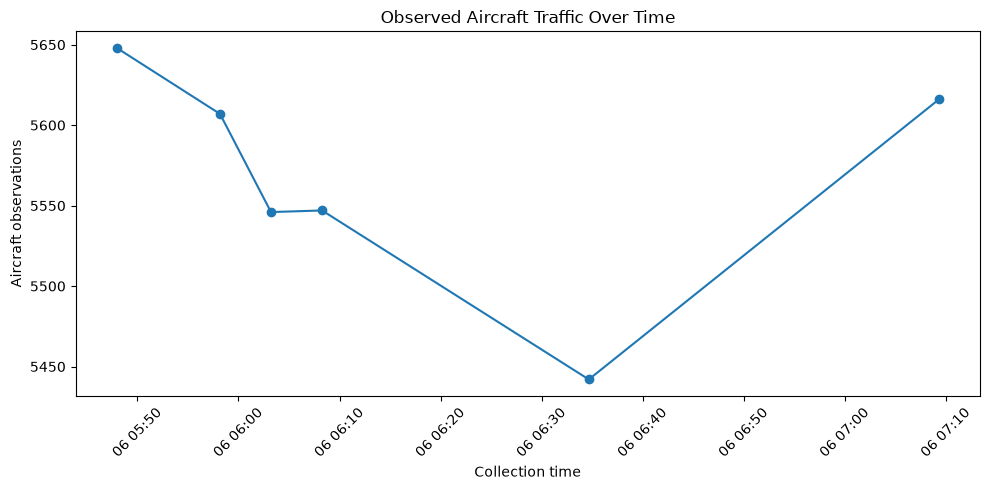

In [134]:
import matplotlib.pyplot as plt

oct6 = snapshot_traffic[
    snapshot_traffic["snapshot_time"].dt.date == snapshot_traffic["snapshot_time"].dt.date.max()
].copy()

plt.figure(figsize=(10, 5))
plt.plot(
    oct6["snapshot_time"],
    oct6["observations"],
    marker="o"
)

plt.title("Observed Aircraft Traffic Over Time")
plt.xlabel("Collection time")
plt.ylabel("Aircraft observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
import ruptures as rpt

print("ruptures is available")

ruptures is available


In [136]:
import numpy as np
import ruptures as rpt

traffic_signal = oct6["observations"].values

model = rpt.Pelt(model="l2").fit(traffic_signal)

change_points = model.predict(pen=5)

print("Traffic observations:", traffic_signal)
print("Change points:", change_points)

Traffic observations: [5648 5607 5546 5547 5442 5616]
Change points: [6]


In [137]:
behavior_features = [
    "velocity",
    "true_track",
    "vertical_rate",
    "geo_altitude",
]

results[behavior_features].describe()

,velocity,true_track,vertical_rate,geo_altitude
count,40966.000000,40966.000000,40966.000000,40966.000000
mean,189.385015,183.171174,-0.087242,7866.343086
std,69.770691,101.006730,5.385859,4296.801567
min,0.000000,0.000000,-103.060000,-716.280000
25%,145.510000,97.812500,-0.650000,3649.980000
50%,214.830000,183.205000,0.000000,9906.000000
75%,235.860000,271.470000,0.000000,11490.960000
max,1642.110000,359.880000,165.810000,21869.400000


In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    results[behavior_features]
)

print("Scaled shape:", X_scaled.shape)
print("Feature means:", X_scaled.mean(axis=0))
print("Feature standard deviations:", X_scaled.std(axis=0))

Scaled shape: (40966, 4)
Feature means: [-2.88615709e-16  6.66036251e-17  0.00000000e+00 -8.88048334e-17]
Feature standard deviations: [1. 1. 1. 1.]


In [139]:
from src.bigquery_client import create_bigquery_client, load_ml_data

client = create_bigquery_client()

ml_data = load_ml_data(client)

print(ml_data.shape)
ml_data.head()

/Users/joelmathooko/Desktop/PROJECTS/Open Sky Aviation/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(40966, 10)


,snapshot_id,collected_at,icao24,observation_time,velocity,true_track,vertical_rate,geo_altitude,latitude,longitude
0,c215bfa3-d3c8-461f-8983-70921df204fd,2026-10-06 06:34:40.075714+00:00,896537,2026-10-06 06:33:44+00:00,14.44,355.91,-103.06,8343.90,23.6587,59.1354
1,c215bfa3-d3c8-461f-8983-70921df204fd,2026-10-06 06:34:40.075714+00:00,76e732,2026-10-06 06:34:32+00:00,25.33,12.91,-42.27,4053.84,-30.5929,115.8844
2,ffa079f9-0bfe-41b7-8c0d-563f7fa146b3,2026-10-06 07:09:18.884632+00:00,4b18f5,2026-10-06 07:09:13+00:00,243.73,160.65,-32.51,8084.82,36.2072,25.0673
3,39d9aeae-6d1a-4e39-a807-3709bd5facf6,2026-10-04 11:26:43.387599+00:00,48b651,2026-10-04 11:25:09+00:00,93.68,96.31,-29.26,1790.70,49.4472,20.0269
4,ffa079f9-0bfe-41b7-8c0d-563f7fa146b3,2026-10-06 07:09:18.884632+00:00,4ca61d,2026-10-06 07:09:14+00:00,171.54,309.04,-29.26,6576.06,59.3708,19.1697


In [146]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

for k, inertia in zip(range(2, 9), inertias):
    print(f"K={k}: inertia={inertia:.2f}")

K=2: inertia=102400.79
K=3: inertia=81104.50
K=4: inertia=63539.71
K=5: inertia=53492.13
K=6: inertia=45554.15
K=7: inertia=42636.13
K=8: inertia=39831.67


In [141]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

results["cluster"] = cluster_labels

print(results["cluster"].value_counts().sort_index())

cluster
0    11863
1     5175
2     4763
3     3673
4     3639
5    11853
Name: count, dtype: int64


In [142]:
cluster_profiles = (
    results
    .groupby("cluster")[behavior_features]
    .mean()
    .round(2)
)

cluster_profiles

,velocity,true_track,vertical_rate,geo_altitude
cluster,,,,
0,223.80,271.60,0.27,10998.93
1,90.37,271.57,-1.91,1879.05
2,91.12,82.33,-1.56,1920.28
3,172.61,182.54,11.04,4838.07
4,193.27,183.73,-9.45,6472.51
5,241.66,96.62,0.36,11100.83


In [143]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.2%}")

PC1: 46.08%
PC2: 25.30%
PC3: 24.66%
PC4: 3.96%


In [144]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=behavior_features,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

loadings.round(3)

,PC1,PC2,PC3,PC4
velocity,0.706,0.015,-0.031,0.707
true_track,-0.037,0.754,0.654,0.050
vertical_rate,0.058,-0.652,0.756,-0.010
geo_altitude,0.705,0.078,0.004,-0.705
